In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from standard_results import final_size_success_mean, final_size_success_sd, probability_failure, failed_dist, final_size_failed_mn

def float_to_str(x, precision=6):
    s = f"{x:.{precision}f}".rstrip('0').rstrip('.')
    return s.replace('.', 'p')

def params_to_filename(params):
    parts = []
    for key in params:
        val = params[key]
        if isinstance(val, float):
            val = float_to_str(val)
        parts.append(f"{key}_{val}")
    return "__".join(parts)

In [3]:
# Params
R0 = 2.0
trec = 4.0
N = 100000
epi_params = {"R0": R0, "trec": trec, "N": N}

# Targets
mn_fail = final_size_failed_mn(R0)
mn_norm = final_size_success_mean(R0)
mn = mn_norm * N
sd = final_size_success_sd(N, R0)
p_fail = probability_failure(R0)

# Data
taus = [0.01, 0.1, 1.0]
dfs = []

# Tau leap
for tau in taus:
    parameters = {"tau": tau}
    fname = params_to_filename( parameters | epi_params )
    dfs.append(pd.read_csv(f"out/tau_fixed__{fname}.csv"))

# # Direct
# fname = params_to_filename( epi_params )
# dfs.append(pd.read_csv(f"out/direct__{fname}.csv"))
# taus.append(0.001)

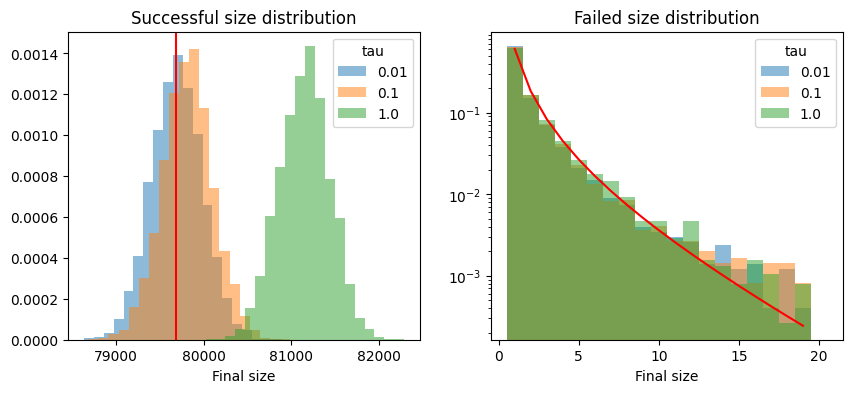

In [9]:
cutoff = mn * 0.5 

fig, ax = plt.subplots(1,2, figsize = (10,4))

for i, df in enumerate(dfs):
    y = df['final_size']
    success = y[y>cutoff]
    ax[0].hist(success, alpha=0.5, density=True, bins=20, label = taus[i])
    # plt.axvline(x=success.mean())
ax[0].legend(title="tau")
ax[0].axvline(x=mn, color="red")
ax[0].set_title("Successful size distribution")

ymax = 20
bins = np.arange(0.5, ymax + 1.5, 1)

for i, df in enumerate(dfs):
    y = df['final_size']
    fail = y[y<ymax]
    ax[1].hist(fail, alpha=0.5, density=True, bins=bins, label = taus[i])
y = np.arange(1, ymax)
f = failed_dist(R0, y)
ax[1].plot(y, f, color="red")
ax[1].legend(title="tau")
ax[1].set_yscale("log")
ax[1].set_title("Failed size distribution")

for axis in ax:
    axis.set_xlabel("Final size")

plt.show()

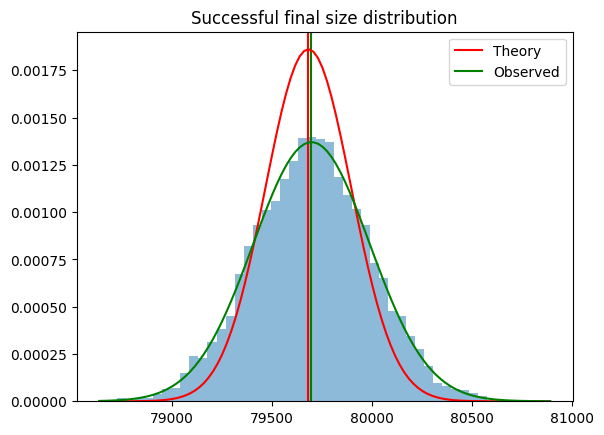

In [14]:
from scipy.stats import norm

# sd = final_size_success_sd(N, R0)

cutoff = 0.5 * mn

j = 0
df = dfs[j]
y = df['final_size']

y = y[y>cutoff]

sd_obs = y.std()
mn_obs = y.mean()

plt.hist(y, alpha=0.5, density=True, bins=50)
plt.axvline(x=mn, color="red")
plt.axvline(x=mn_obs, color="green")

x = np.linspace( y.min(), y.max(), 100)
y = norm.pdf(x, mn, sd)
plt.plot(x, y, color="red", label="Theory")
y = norm.pdf(x, mn_obs, sd_obs)
plt.plot(x, y, color="green", label="Observed")
plt.legend()
plt.title("Successful final size distribution")
plt.show()


In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (15,4))

cutoff = mn - 6 * sd

axis= ax[0]
for i, df in enumerate(dfs):
    y = df['final_size']

    y = y[y<cutoff]

    mn_obs = y.mean()

    axis.scatter(taus[i], mn_obs, color="black")
axis.axhline(y=mn_fail, color="red")
axis.set_xscale("log")
axis.set_title("Final size mean (failed)")
axis.set_ylim( 0, mn_fail * 2)

axis= ax[1]
for i, df in enumerate(dfs):
    y = df['final_size']

    y = y[y>cutoff] / N

    mn_obs = y.mean()

    axis.scatter(taus[i], mn_obs, color="black")
axis.axhline(y=mn_norm, color="red")
axis.set_xscale("log")
axis.set_title("Final size mean")
axis.set_ylim( max(mn_norm*0.8, 0), min(mn_norm*1.2, 1))

axis = ax[2]
for i, df in enumerate(dfs):
    y = df['final_size']

    y = y[y>cutoff]

    sd_obs = y.std()

    axis.scatter(taus[i], sd_obs, color="black")
axis.axhline(y=sd, color="red")
axis.set_xscale("log")
axis.set_title("Final size SD")

axis = ax[3]

for i, df in enumerate(dfs):
    y = df['final_size']

    n_sim = len(y)
    n_fail = len(y[y<cutoff])

    p_fail_obs = n_fail / n_sim

    axis.scatter(taus[i], p_fail_obs, color="black")
axis.axhline(y=p_fail, color="red")
axis.set_xscale("log")
axis.set_title("Extinction probability")
axis.set_ylim( 0.2 , 1)

plt.tight_layout()
plt.show()

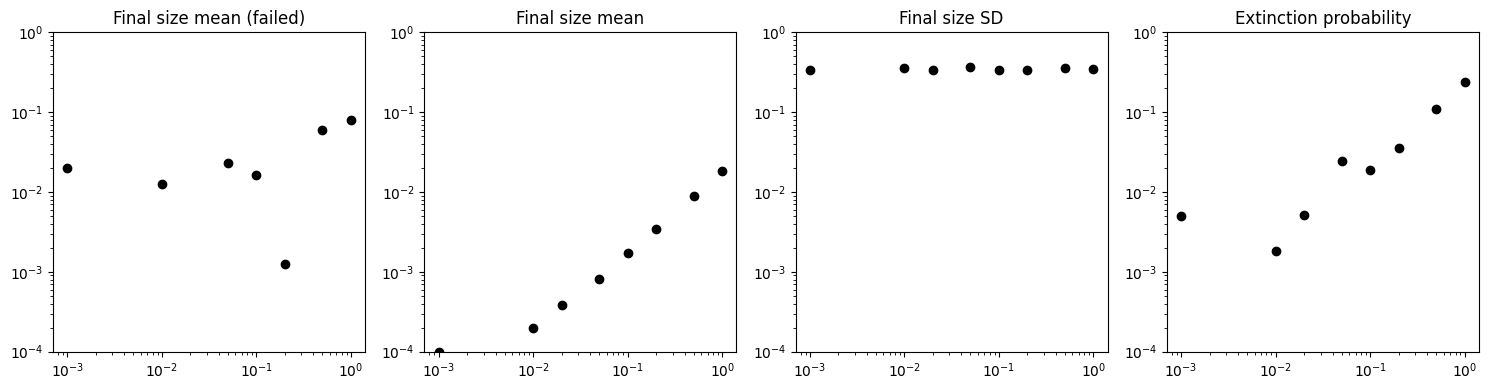

In [57]:
fig, ax = plt.subplots(1, 4, figsize = (15,4))

cutoff = mn - 6 * sd

axis= ax[0]
for i, df in enumerate(dfs):
    y = df['final_size']

    y = y[y<cutoff]
    mn_obs = y.mean()

    err = abs(mn_obs - mn_fail) / mn_fail

    axis.scatter(taus[i], err, color="black")
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_title("Final size mean (failed)")

axis= ax[1]
for i, df in enumerate(dfs):
    y = df['final_size']

    y = y[y>cutoff] / N

    mn_obs = y.mean()

    err = abs(mn_obs - mn_norm)/mn_norm

    axis.scatter(taus[i], err, color="black")
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_title("Final size mean")

axis = ax[2]
for i, df in enumerate(dfs):
    y = df['final_size']

    y = y[y>cutoff]

    sd_obs = y.std()

    err = abs(sd_obs - sd)/sd

    axis.scatter(taus[i], err, color="black")
axis.set_yscale("log")
axis.set_xscale("log")
axis.set_title("Final size SD")

axis = ax[3]

for i, df in enumerate(dfs):
    y = df['final_size']

    n_sim = len(y)
    n_fail = len(y[y<cutoff])

    p_fail_obs = n_fail / n_sim

    err = abs(p_fail_obs - p_fail) / p_fail

    axis.scatter(taus[i], err, color="black")
axis.set_yscale("log")
axis.set_xscale("log")
axis.set_title("Extinction probability")

for axis in ax:
    axis.set_ylim(1e-4, 1e-0)

plt.tight_layout()
plt.show()

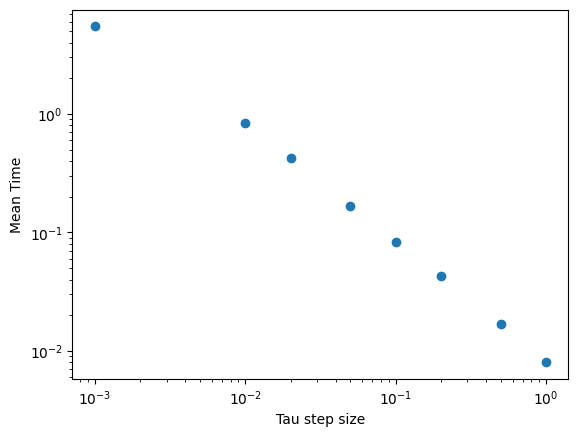

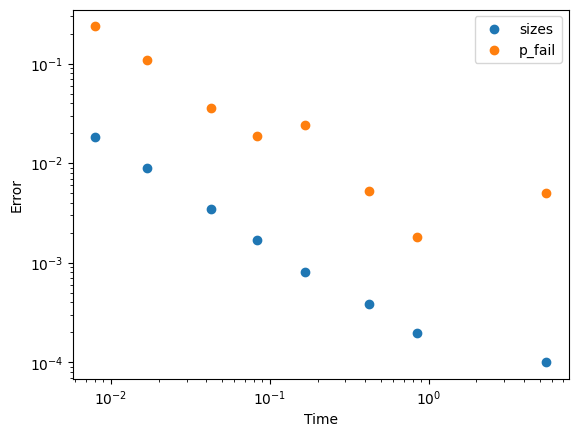

In [58]:
times = []

sizes = []

p_fails = []

for i, df in enumerate(dfs):
    filtered = df[df['final_size'] > cutoff]
    times.append(filtered['cpu_time_seconds'].mean())

    y = df['final_size']
    y = y[y>cutoff] / N
    mn_obs = y.mean()
    err = abs(mn_obs - mn_norm)/mn_norm
    sizes.append(err)

    y = df['final_size']

    n_sim = len(y)
    n_fail = len(y[y<cutoff])

    p_fail_obs = n_fail / n_sim

    p_fails.append(abs(p_fail_obs - p_fail) / p_fail)

plt.scatter(taus, times)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Tau step size")
plt.ylabel("Mean Time")
plt.show()

plt.scatter(times, sizes, label = "sizes")
plt.scatter(times, p_fails, label = "p_fail")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

In [59]:
# import numpy as np

# def sellke_final_size_sd(N, R0, gamma, I0=1, n_sim=5000):
#     """
#     Monte Carlo SD of final epidemic size (successful outbreaks only)
#     for classical Markov SIR using Sellke construction.
#     """

#     beta = R0 * gamma
#     final_sizes = []

#     for _ in range(n_sim):

#         # Infectious periods
#         T = np.random.exponential(1/gamma, size=N)

#         # Resistances
#         E = np.random.exponential(1, size=N)
#         E.sort()

#         cumulative_pressure = 0.0
#         k = I0

#         while k < N:
#             cumulative_pressure += beta * T[k-1] / N
#             if cumulative_pressure < E[k]:
#                 break
#             k += 1

#         final_sizes.append(k)

#     final_sizes = np.array(final_sizes)

#     # Define success however you prefer:
#     # e.g. major outbreak threshold at N^(2/3)
#     threshold = N**(2/3)
#     successful = final_sizes[final_sizes > threshold]

#     return np.std(successful, ddof=1)